# Creating Dataset for CLIP-Based Model

## Extract UI Elements

In [12]:
import pandas as pd

# Load CSV
train_df = pd.read_csv('../data/screen_annotation/train.csv')
test_df = pd.read_csv('../data/screen_annotation/test.csv')
val_df = pd.read_csv('../data/screen_annotation/valid.csv')
combined = pd.concat([train_df, test_df, val_df])
combined['screen_annotation'].iloc[0]

'TEXT Currency code 79 923 78 111, LIST_ITEM 45 955 116 179 (RADIO_BUTTON 93 160 129 166, LABEL USD 205 305 131 163), LIST_ITEM 43 955 181 245 (RADIO_BUTTON 97 157 196 230, LABEL UYU 202 306 198 229), LIST_ITEM 42 958 247 310 (RADIO_BUTTON 96 155 263 296, LABEL UZS 203 303 264 294), LIST_ITEM 43 957 313 376 (RADIO_BUTTON 96 156 328 361, LABEL VEB 206 303 330 360), LIST_ITEM 41 959 379 441 (RADIO_BUTTON 97 156 394 428, LABEL VND 205 308 395 425), LIST_ITEM 42 959 444 507 (RADIO_BUTTON 95 155 458 493, LABEL VUV 205 307 461 491), LIST_ITEM 42 957 510 573 (RADIO_BUTTON 95 157 524 558, LABEL WST 206 312 528 557), LIST_ITEM 43 959 576 638 (RADIO_BUTTON 95 155 589 623, LABEL XAF 204 302 593 623), LIST_ITEM 43 958 641 703 (RADIO_BUTTON 95 156 656 689, LABEL XCD 204 305 659 688), LIST_ITEM 42 959 706 769 (RADIO_BUTTON 95 156 721 755, LABEL XOF 203 301 725 753), LIST_ITEM 43 959 772 835 (RADIO_BUTTON 96 156 786 820, LABEL XPF 204 300 791 820), LIST_ITEM 45 956 838 903 (RADIO_BUTTON 95 158 854 88

In [13]:
def extract_ui_elements(annotation_string):
    """
    Extract all UI elements from hierarchical annotation string into a flat list.
    Uses a stack-based approach to handle nested parentheses.
    """
    elements = []
    current_element = ""
    paren_depth = 0
    
    # Split by commas at the top level, respecting parentheses
    for char in annotation_string:
        if char == '(':
            paren_depth += 1
            current_element += char
        elif char == ')':
            paren_depth -= 1
            current_element += char
        elif char == ',' and paren_depth == 0:
            # Top-level comma found, process current element
            if current_element.strip():
                process_element(current_element.strip(), elements)
            current_element = ""
        else:
            current_element += char
    
    # Process the last element
    if current_element.strip():
        process_element(current_element.strip(), elements)
    
    return elements


def process_element(element_str, elements):
    """
    Recursively process an element and its children.
    """
    # Find the first opening parenthesis
    paren_index = element_str.find('(')
    
    if paren_index == -1:
        # No children -> parse this element directly
        parse_and_add_element(element_str, elements)
    else:
        # Has children -> parse parent first, then children
        parent_part = element_str[:paren_index].strip()
        parse_and_add_element(parent_part, elements)
        
        # Extract children content (remove outer parentheses)
        children_part = element_str[paren_index+1:-1]
        
        # Split children by commas at depth 0 using stack approach
        current_child = ""
        paren_depth = 0
        
        for char in children_part:
            if char == '(':
                paren_depth += 1
                current_child += char
            elif char == ')':
                paren_depth -= 1
                current_child += char
            elif char == ',' and paren_depth == 0:
                # Top-level comma in children
                if current_child.strip():
                    process_element(current_child.strip(), elements)
                current_child = ""
            else:
                current_child += char
        
        # Process the last child
        if current_child.strip():
            process_element(current_child.strip(), elements)


def parse_and_add_element(element_str, elements):
    """
    Parse a single element string and add it to the elements list.
    Format: TYPE text x1 x2 y1 y2
    """
    parts = element_str.split()
    if len(parts) < 5:
        return
    
    element_type = parts[0]
    
    # Last 4 parts are coordinates
    try:
        x1 = int(parts[-4])
        x2 = int(parts[-3])
        y1 = int(parts[-2])
        y2 = int(parts[-1])
        
        # Everything between type and coordinates is the text/label
        text = ' '.join(parts[1:-4]) if len(parts) > 5 else ""
        
        elements.append({
            'type': element_type,
            'text': text,
            'x1': x1,
            'y1': y1,
            'x2': x2,
            'y2': y2
        })
    except Exception:
        pass

def extracted_dataframe(df):
    extracted_dict = {'screen_id': [], 'type': [], 'text': [], 'x1': [], 'y1': [], 'x2': [], 'y2': []}

    for index, row in df.iterrows():
        screen_id = row['screen_id']
        screen_annotation = row['screen_annotation']
        extracted_elements = extract_ui_elements(screen_annotation)

        for el in extracted_elements:
            extracted_dict['screen_id'].append(screen_id)
            extracted_dict['type'].append(el['type'])
            extracted_dict['text'].append(el['text'])
            extracted_dict['x1'].append(el['x1'])
            extracted_dict['y1'].append(el['y1'])
            extracted_dict['x2'].append(el['x2'])
            extracted_dict['y2'].append(el['y2'])
    extracted_df = pd.DataFrame(extracted_dict)
    return extracted_df

df = extracted_dataframe(combined)

## Check Extraction Quality

In [14]:
# Show basic info
print('Describe')
display(df.describe())
print('')
print('Info')
display(df.info())

Describe


,screen_id,x1,y1,x2,y2
count,518749.000000,518749.000000,518749.000000,518749.000000,518749.000000
mean,35956.670052,265.020684,452.084877,637.477512,510.243842
std,20961.315521,292.216540,301.000467,314.761506,302.095995
min,2.000000,0.000000,0.000000,13.000000,1.000000
25%,17593.000000,28.000000,175.000000,335.000000,232.000000
50%,36438.000000,143.000000,429.000000,682.000000,493.000000
75%,53902.000000,462.000000,714.000000,961.000000,781.000000
max,72215.000000,985.000000,981.000000,999.000000,999.000000



Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518749 entries, 0 to 518748
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   screen_id  518749 non-null  int64 
 1   type       518749 non-null  object
 2   text       518749 non-null  object
 3   x1         518749 non-null  int64 
 4   y1         518749 non-null  int64 
 5   x2         518749 non-null  int64 
 6   y2         518749 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 27.7+ MB


None

Note that coordinates range from 0-999 (according to Google). There are no nulls but some text is empty. We will get rid of UI elements with no text since most UI elements that users would be drawn to have text associated. Also, suppose there's several buttons on the screen with no text. If the user says, "tap the button," then it will be hard to distinguish which button they meant. Only UI elements with text provide enough context for meaningful predictions.

In [15]:
# Strip text
df['text'] = df['text'].apply(lambda x: x.strip())

# Get rid of entries with no text
df = df[df['text'] != '']

In [16]:
# Get number of occurrences for each UI type
occurrences = {"type": [], "num_occurrences": []}

for el in df['type'].unique():

    is_candidate = True
    
    # Types are always uppercase
    if el.upper() != el:
        is_candidate = False

    # Types only have letters or underscores
    for c in el:
        if (not c.isalpha()) and (c != "_"):
            is_candidate = False
            break

    if is_candidate:
        num_occurrences = len(df.query('type == @el'))
        occurrences['type'].append(el)
        occurrences['num_occurrences'].append(num_occurrences)

occurrences = pd.DataFrame(occurrences).sort_values(by='num_occurrences', ascending=False)

In [17]:
# Show number of ocurrences for each UI type, ordered by most common first
for index, row in occurrences.iterrows():
    print(f"{row['type']:20} | {row['num_occurrences']}")

TEXT                 | 160368
PICTOGRAM            | 141210
BUTTON               | 32307
IMAGE                | 21770
LABEL                | 15646
TEXT_INPUT           | 265
CA                   | 122
I                    | 96
GOT                  | 14
A                    | 14
CHECKBOX             | 13
NY                   | 11
LIST_ITEM            | 11
CC                   | 10
AND                  | 10
CO                   | 9
DO                   | 8
DECEMBER             | 8
THE                  | 8
UNITED               | 8
MD                   | 8
IL                   | 7
AOSP                 | 6
OR                   | 6
YOU                  | 5
TX                   | 5
VA                   | 5
JANUARY              | 5
MA                   | 4
NOT                  | 4
TITANIUM             | 4
NJ                   | 4
US                   | 4
APR                  | 4
FGTEEV               | 3
TERMS                | 3
C                    | 3
PDF                  | 3
CCO             

It seems like categories for UI are the following:
- TEXT
- PICTOGRAM
- BUTTON
- IMAGE
- LABEL
- TEXT_INPUT
- CHECKBOX
- LIST_ITEM

Any other types will be disregarded because they are mistakes from extraction.

In [18]:
# Keep relevant types
df = df[df['type'].isin(['TEXT', 'PICTOGRAM', 'BUTTON', 'IMAGE', 'LABEL', 'TEXT_INPUT', 'CHECKBOX', 'LIST_ITEM'])]

In [19]:
# Show basic info
print('Describe')
display(df.describe())
print('')
print('Info')
display(df.info())

Describe


,screen_id,x1,y1,x2,y2
count,371590.000000,371590.000000,371590.000000,371590.000000,371590.000000
mean,35919.868145,311.091052,460.891822,556.438925,512.312635
std,20945.019626,296.426487,308.829958,303.267859,305.966228
min,2.000000,0.000000,0.000000,13.000000,1.000000
25%,17558.000000,43.000000,171.000000,266.000000,226.000000
50%,36404.000000,185.000000,438.000000,536.000000,494.000000
75%,53817.000000,520.000000,741.000000,846.000000,795.000000
max,72215.000000,985.000000,981.000000,999.000000,999.000000



Info
<class 'pandas.core.frame.DataFrame'>
Index: 371590 entries, 0 to 518748
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   screen_id  371590 non-null  int64 
 1   type       371590 non-null  object
 2   text       371590 non-null  object
 3   x1         371590 non-null  int64 
 4   y1         371590 non-null  int64 
 5   x2         371590 non-null  int64 
 6   y2         371590 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 22.7+ MB


None

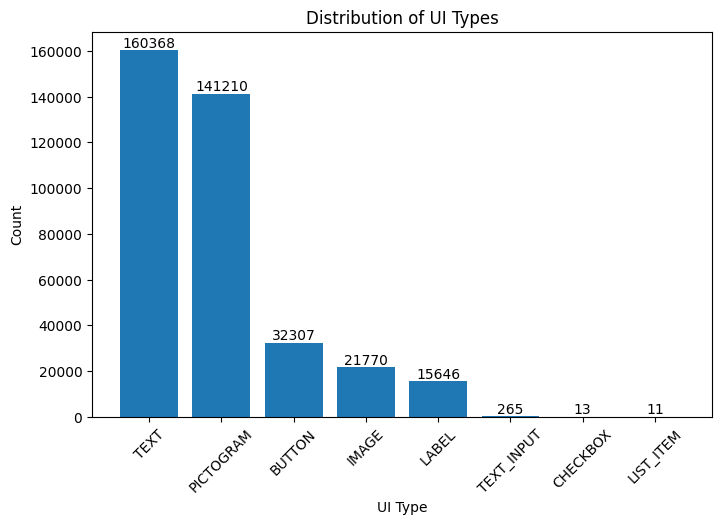

In [20]:
import matplotlib.pyplot as plt

# Plotting distribution of UI types
type_counts = df['type'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(type_counts.index, type_counts.values)
plt.title('Distribution of UI Types')
plt.xlabel('UI Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Adding labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center', va='bottom', fontsize=10
    )

plt.show()

A few types have very low counts so let's inspect them.

In [21]:
for UI_type in ['TEXT_INPUT', 'CHECKBOX', 'LIST_ITEM']:
    print(UI_type)
    display(df[df['type'] == UI_type])
    print()

TEXT_INPUT


,screen_id,type,text,x1,y1,x2,y2
1556,21501,TEXT_INPUT,appcrawler6@gmail.com,40,306,953,363
3202,63113,TEXT_INPUT,San,124,163,890,223
5742,15085,TEXT_INPUT,1,184,603,345,632
5753,15085,TEXT_INPUT,0,208,675,355,703
5755,15085,TEXT_INPUT,OTHER 1,19,710,716,740
...,...,...,...,...,...,...,...
511742,29040,TEXT_INPUT,distance / volume,75,668,380,688
511746,29040,TEXT_INPUT,MM/DD/YYYY,75,777,325,800
516877,13655,TEXT_INPUT,java,51,431,948,483
516878,13655,TEXT_INPUT,java,57,440,146,473



CHECKBOX


,screen_id,type,text,x1,y1,x2,y2
155237,28603,CHECKBOX,"894 972 620 665), LIST_ITEM",0,684,996,830
155244,28603,CHECKBOX,"896 972 769 812), LIST_ITEM",1,832,994,871
382384,9701,CHECKBOX,"922 999 179 227), LIST_ITEM",0,248,998,320
382387,9701,CHECKBOX,"922 998 252 297), LIST_ITEM",0,318,998,390
382390,9701,CHECKBOX,"922 998 321 368), LIST_ITEM",0,391,998,462
382393,9701,CHECKBOX,"922 996 392 439), LIST_ITEM",0,462,998,534
382396,9701,CHECKBOX,"922 996 461 509), LIST_ITEM",0,535,998,605
382399,9701,CHECKBOX,"920 994 534 580), LIST_ITEM",0,605,998,677
382402,9701,CHECKBOX,"924 996 605 651), LIST_ITEM",0,675,999,746
382405,9701,CHECKBOX,"924 996 677 723), LIST_ITEM",0,744,999,818



LIST_ITEM


,screen_id,type,text,x1,y1,x2,y2
315009,33670,LIST_ITEM,"514 991 106 170), TEXT 45 Lincoln Heights - Dw...",512,172,991,234
315010,33670,LIST_ITEM,"512 992 172 233), LIST_ITEM",0,237,512,294
315012,33670,LIST_ITEM,"512 993 236 298), LIST_ITEM",0,302,513,361
315014,33670,LIST_ITEM,"512 992 302 364), LIST_ITEM",0,371,512,429
315017,33670,LIST_ITEM,"509 993 434 495), LIST_ITEM",0,505,518,561
315019,33670,LIST_ITEM,"511 993 501 561), LIST_ITEM",0,573,501,628
419007,70091,LIST_ITEM,"129 815 111 158), LIST_ITEM",126,167,878,570
490063,24405,LIST_ITEM,"329 437 491 554), PICTOGRAM star",442,491,553,553
490064,24405,LIST_ITEM,"444 550 493 550), PICTOGRAM star",562,491,672,554
490065,24405,LIST_ITEM,"557 668 493 554), PICTOGRAM star",681,491,790,554


CHECKBOX and LIST_ITEM seem to be full of extraction mistakes so we will remove them.

In [22]:
# Remove CHECKBOX and LIST_ITEM
df = df.query('type != "CHECKBOX" and type != "LIST_ITEM"')

In [23]:
# Showing text that contains parenthesis or commas
for item in df['text']:
    for c in item:
        if c == "(" or c == ")" or c == ",":
            print(item)

You need to sign in to do that :) 244 755 603 632, BUTTON SIGN IN
You need to sign in to do that :) 244 755 603 632, BUTTON SIGN IN
8-)
* Remove ads and this dialog! :) 121 687 608 632), NAVIGATION_BAR
* Remove ads and this dialog! :) 121 687 608 632), NAVIGATION_BAR
* Remove ads and this dialog! :) 121 687 608 632), NAVIGATION_BAR
BUY ELITE 691 903 669 732), BUTTON OK
BUY ELITE 691 903 669 732), BUTTON OK
a) All vehicles are traveling near or at the same speed
b) One lane of traffic traveling much slower than the others 6 991 578 719, BUTTON
b) One lane of traffic traveling much slower than the others 6 991 578 719, BUTTON
c) One vehicle is traveling faster or slower than the flow of traffic 16 980 778 808)), NAVIGATION_BAR
c) One vehicle is traveling faster or slower than the flow of traffic 16 980 778 808)), NAVIGATION_BAR
c) One vehicle is traveling faster or slower than the flow of traffic 16 980 778 808)), NAVIGATION_BAR
c) One vehicle is traveling faster or slower than the flow 

Since parenthesis and commas were used to parse the annotation string, text with parenthesis and commas will be removed because it usually contains errors.

In [24]:
# Remove text with parenthesis or commas (likely has errors)
df['text'] = df['text'].apply(lambda x: None if (('(' in x) or (')' in x) or (',' in x)) else x)
df = df[df['text'].notna()]

In [25]:
# Check duplicates
display(df[df.duplicated()])

,screen_id,type,text,x1,y1,x2,y2
493440,54233,LABEL,appcrawler2AndroidAP,36,164,505,200


In [29]:
# Drop duplicates
df = df.drop_duplicates()

In [30]:
# Show basic info
print('Describe')
display(df.describe())
print('')
print('Info')
display(df.info())

Describe


,screen_id,x1,y1,x2,y2
count,371146.000000,371146.000000,371146.000000,371146.000000,371146.000000
mean,35919.593497,311.229266,460.660840,556.133756,512.146476
std,20945.860032,296.419999,308.832179,303.201918,305.913444
min,2.000000,0.000000,0.000000,13.000000,1.000000
25%,17558.000000,43.000000,171.000000,266.000000,226.000000
50%,36404.000000,185.000000,438.000000,536.000000,494.000000
75%,53806.000000,520.000000,740.000000,845.000000,795.000000
max,72215.000000,985.000000,981.000000,999.000000,999.000000



Info
<class 'pandas.core.frame.DataFrame'>
Index: 371146 entries, 0 to 518748
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   screen_id  371146 non-null  int64 
 1   type       371146 non-null  object
 2   text       371146 non-null  object
 3   x1         371146 non-null  int64 
 4   y1         371146 non-null  int64 
 5   x2         371146 non-null  int64 
 6   y2         371146 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 22.7+ MB


None

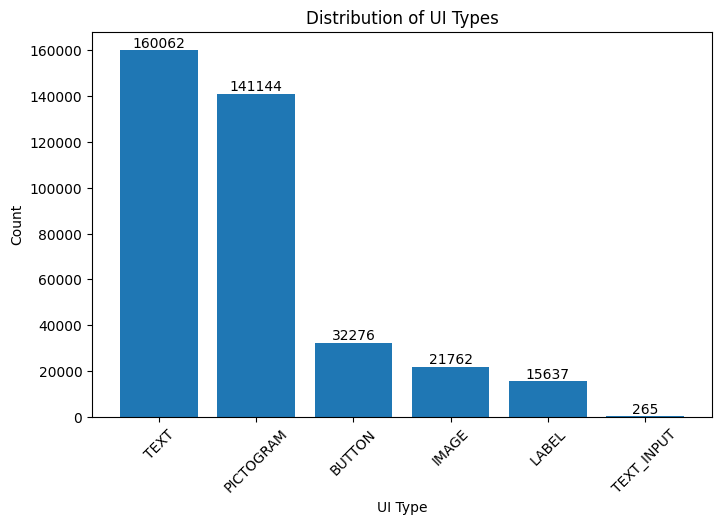

In [31]:
# Plotting distribution of UI types
type_counts = df['type'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(type_counts.index, type_counts.values)
plt.title('Distribution of UI Types')
plt.xlabel('UI Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Adding labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center', va='bottom', fontsize=10
    )

plt.show()

## Visualize Bounding Boxes

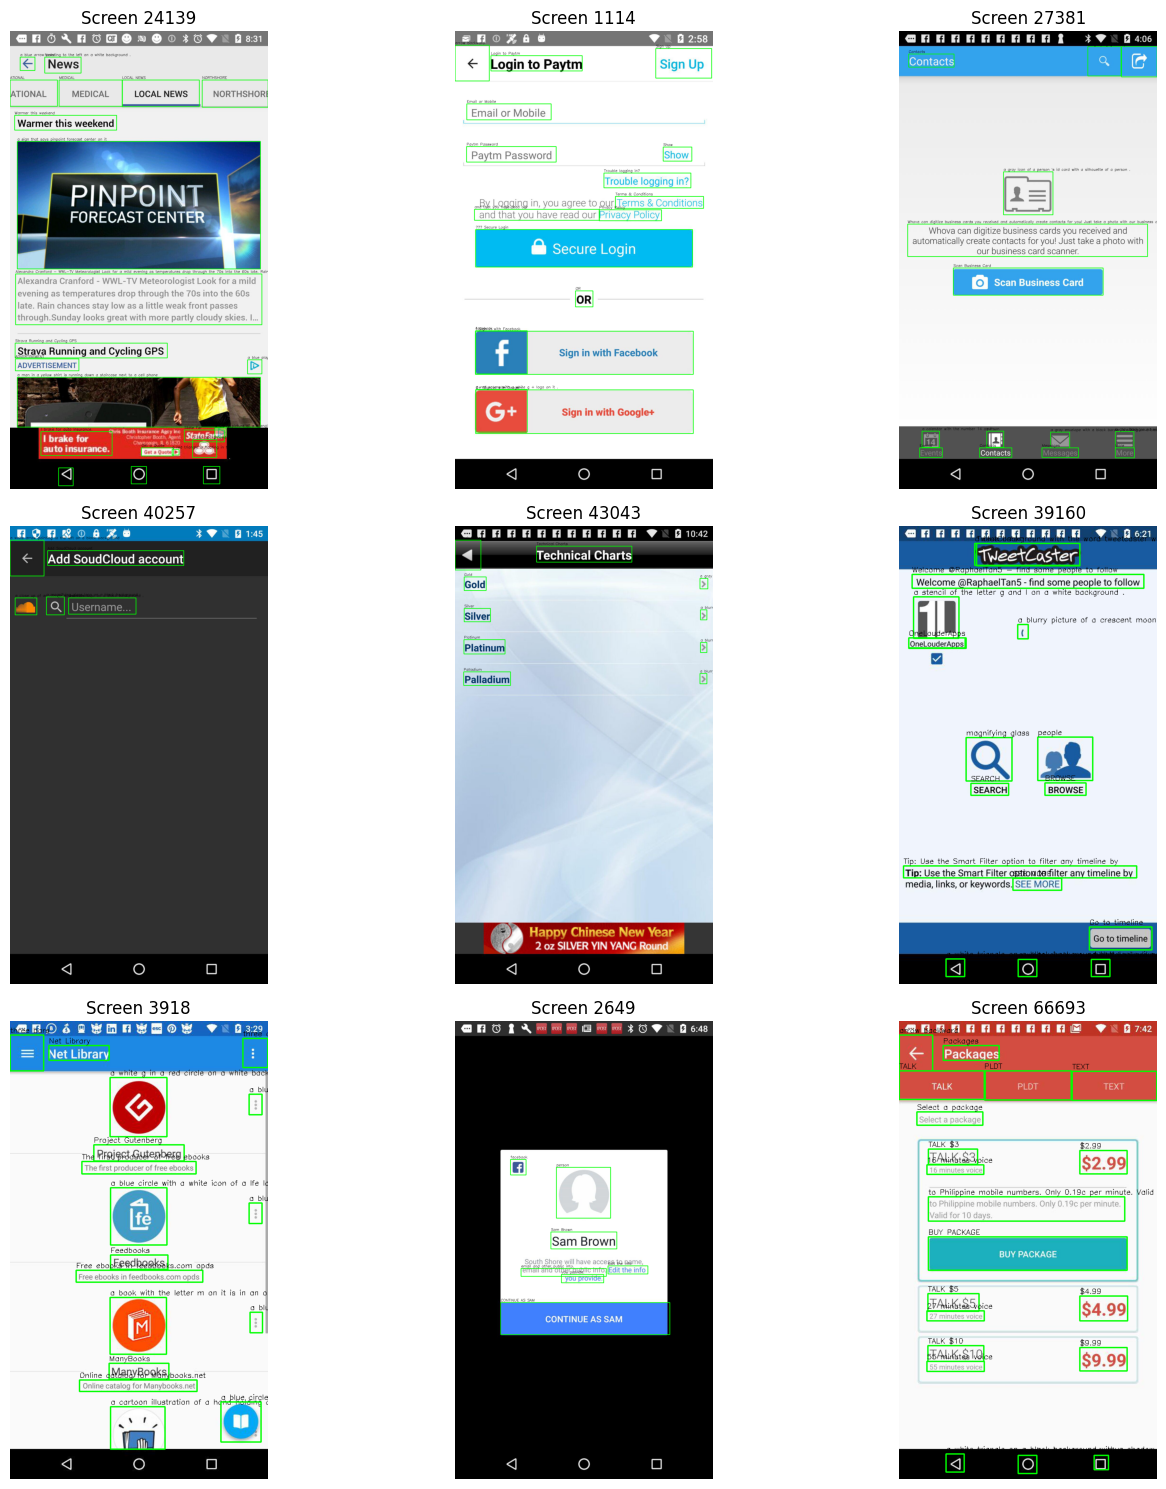

In [32]:
import cv2
import pandas as pd
import random

random.seed(42)

def draw_bboxes_on_image(img, annotations):
    """Draw bounding boxes and text labels on an image."""
    img_h, img_w = img.shape[:2]

    for _, row in annotations.iterrows():
        x1, x2, y1, y2 = row['x1'], row['x2'], row['y1'], row['y2']
        # Scale coordinates from 0-999 to actual image size
        x1 = int(x1 / 999 * img_w)
        x2 = int(x2 / 999 * img_w)
        y1 = int(y1 / 999 * img_h)
        y2 = int(y2 / 999 * img_h)

        # Draw rectangle
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Add text if available
        if pd.notna(row['text']) and row['text'] != '':
            cv2.putText(img, str(row['text']), (x1, max(y1-5, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    return img

# Pick 9 random screens
screen_ids = random.sample(list(df['screen_id'].unique()), 9)

# Create a 3x3 grid for plotting
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, screen_id in enumerate(screen_ids):
    image_path = f"../data/screen_annotation/images/{screen_id}.jpg"
    annotations = df[df["screen_id"] == screen_id]

    # Load the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Warning: Image {screen_id} not found.")
        continue

    # Convert BGR to RGB for matplotlib
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = draw_bboxes_on_image(img, annotations)

    # Plot it in the grid
    axes[i].imshow(img)
    axes[i].set_title(f"Screen {screen_id}")
    axes[i].axis('off')

# Hide any empty subplots in case there were fewer than 9 images
for j in range(i+1, 9):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


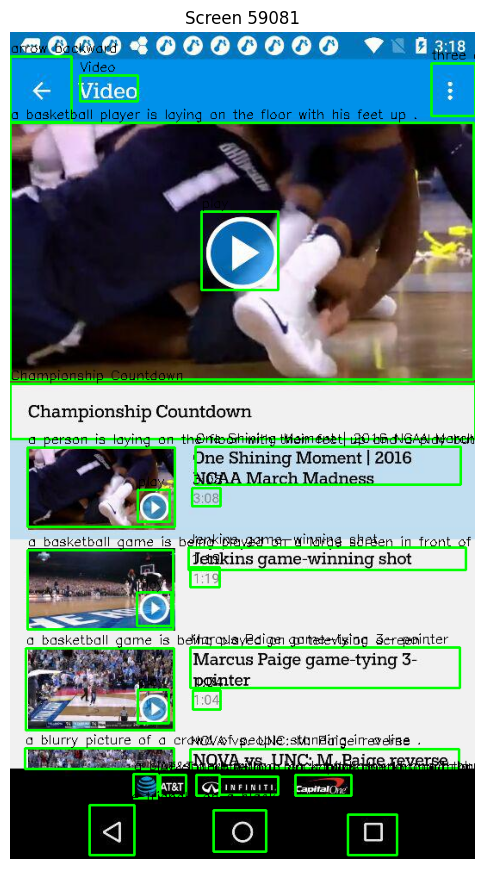

In [38]:
screen_id = random.choice(df['screen_id'].unique())
image_path = f"../data/screen_annotation/images/{screen_id}.jpg"
annotations = df[df["screen_id"] == screen_id]

# Load the image
img = cv2.imread(image_path)
if img is None:
    raise ValueError(f"Image {screen_id} not found at {image_path}")

# Convert BGR to RGB for matplotlib
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Draw bounding boxes and text
img = draw_bboxes_on_image(img, annotations)

# Show the image
plt.figure(figsize=(6, 12))
plt.imshow(img)
plt.title(f"Screen {screen_id}")
plt.axis('off')
plt.show()

In [34]:
# Show distribution of screen id
print(f"{'Screen ID':10} | Count")
print('------------------------------')
for screen_id, count in df['screen_id'].value_counts().items():
    print(f'{screen_id:<10} | {count}')

Screen ID  | Count
------------------------------
53569      | 110
19833      | 105
61970      | 89
50483      | 87
11711      | 83
11234      | 81
7373       | 81
2592       | 79
47780      | 77
41967      | 77
31511      | 77
42309      | 76
71462      | 76
57725      | 76
63962      | 75
31520      | 75
2591       | 75
7025       | 74
57248      | 74
43648      | 74
20479      | 73
46175      | 73
48742      | 73
27776      | 73
46188      | 72
65193      | 72
31506      | 72
42279      | 72
42157      | 71
69817      | 71
30291      | 71
45012      | 70
45410      | 70
39787      | 70
7374       | 69
28324      | 69
43130      | 69
29331      | 69
47328      | 68
16956      | 68
53603      | 68
62286      | 68
26142      | 67
15177      | 67
43042      | 67
15179      | 67
20384      | 67
5478       | 66
16040      | 66
22920      | 66
15948      | 66
67240      | 66
54349      | 65
48759      | 65
51493      | 65
18782      | 65
40367      | 65
18784      | 65
7786       | 64
4304

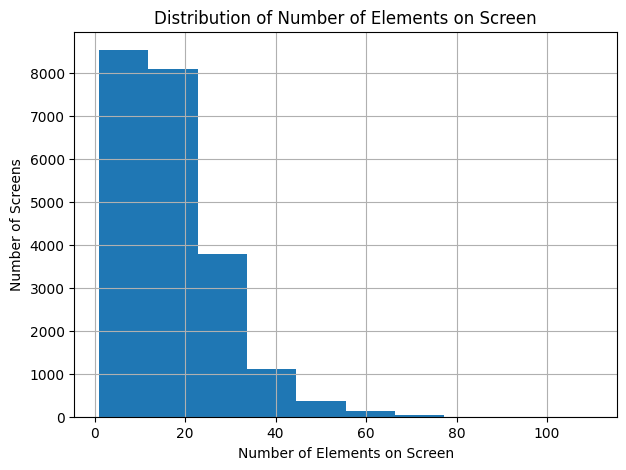

In [35]:
# Plot distribution of screen ID counts
plt.figure(figsize=(7, 5))
df['screen_id'].value_counts().hist()
plt.title('Distribution of Number of Elements on Screen')
plt.xlabel('Number of Elements on Screen')
plt.ylabel('Number of Screens')
plt.show()

Some screens appear much more frequently in the final dataframe than others so this is important to keep in mind.

In [36]:
# Save data
df.to_csv('extracted_annotations.csv', index=False)

In [ ]:
import os

# Delete images that aren't in annotated dataset
df = pd.read_csv("../data/screen_annotation/extracted_annotations.csv")
screen_ids_needed = df["screen_id"].unique()

for file_name in os.listdir("../data/screen_annotation/images"):
    
    need_file = False

    if ".jpg" in file_name:
        screen_id = int(file_name.split(".jpg")[0])
        if screen_id in screen_ids_needed:
            need_file = True

    if not need_file:
        os.remove("../data/screen_annotation/images/" + file_name)

**WARNING**: Note that there were extraction errors. Not all UI elements are in the final dataframe. Some UI types can be misleading (e.g. if a button has text, it might be BUTTON or TEXT type and this is not consistent for all buttons). It is also possible that some annotations are wrong due to parsing issues.